**Tutorial Code by Amirhossein Ahrari YouTube:** https://www.youtube.com/@amirhosseinahrarigee

**Tutorial Video: PySTAC Tutorial-8: Sentinel-2 NDVI Phenological Metrics Calculation in Python**

This code is part of a tutorial series on python eo programming techniques
presented on the Amirhossein Ahrari YouTube channel. You are free to use and modify
this code for academic and non-academic purposes. Don't forget to subscribe to
the Amirhossein Ahrari channel and follow the videos to support the instructor.

In [ ]:
!pip install -q pystac-client stackstac

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.9 MB/s eta 0:00:00


In [ ]:
from pystac_client import Client

In [ ]:
catalog = Client.open(
    'https://earth-search.aws.element84.com/v1'
)

In [ ]:
for collection in catalog.get_collections():
  print(collection.id)

sentinel-2-pre-c1-l2a
cop-dem-glo-30
naip
cop-dem-glo-90
landsat-c2-l2
sentinel-2-l2a
sentinel-2-l1c
sentinel-2-c1-l2a
sentinel-1-grd


In [ ]:
roi = [46.09378, 36.897313, 46.113086, 36.913243]

In [ ]:
search = catalog.search(
    collections = ['sentinel-2-c1-l2a'],
    bbox = roi,
    datetime = '2024'
)

In [ ]:
items = search.item_collection()

/usr/local/lib/python3.13/dist-packages/pystac/extensions/storage.py:724: UserWarning: Could not parse bucket/account from href. The following assets were not migrated: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail']
  warnings.warn(


In [ ]:
len(items)

75

In [ ]:
items[0].assets.keys()

dict_keys(['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail'])

In [ ]:
import stackstac

In [ ]:
ds = stackstac.stack(
    items,
    assets = ['red','nir','scl'],
    bounds_latlon = roi,
    resolution = 10,
    epsg = 3857
)

In [ ]:
ds_clean = (
    ds.to_dataset('band')
    .drop_dims('band')
    .reset_coords(drop = True)
    .drop_attrs()
)

In [ ]:
mask = ds_clean.scl.isin([3,8,9,10]).astype(int)
ds_mask = ds_clean[['red','nir']].where(mask == 0)

In [ ]:
nir = ds_mask['nir']
red = ds_mask['red']
ndvi = (nir - red) / (nir + red)

In [ ]:
ndvi_weekly = ndvi.resample(time = 'W').max('time')

In [ ]:
from dask.diagnostics import ProgressBar

In [ ]:
import warnings
warnings.filterwarnings('ignore', category = RuntimeWarning)
import logging
logging.getLogger().setLevel(logging.ERROR)

In [ ]:
with ProgressBar():
  ndvi_weekly = ndvi_weekly.compute()

[########################################] | 100% Completed | 47.14 s


In [ ]:
ndvi_int = ndvi_weekly.interpolate_na(
    dim = 'time', method = 'linear', fill_value = 'extrapolate'
)
ndvi_int = ndvi_int.ffill(dim = 'time').bfill(dim = 'time')

In [ ]:
ndvi_trans = ndvi_int.transpose('y','x','time')

In [ ]:
ndvi_vals = ndvi_trans.values

In [ ]:
ndvi_vals.shape

(223, 216, 52)

In [ ]:
from scipy.signal import savgol_filter

In [ ]:
ndvi_filter = savgol_filter(
    ndvi_vals,
    window_length = 5,
    polyorder = 2,
    axis = -1,
    mode = 'interp'
)

In [ ]:
import xarray as xr

In [ ]:
ndvi_arr = xr.DataArray(
    ndvi_filter,
    dims = ndvi_trans.dims,
    coords = ndvi_trans.coords
)

In [ ]:
ndvi_min = ndvi_arr.min(dim = 'time')
ndvi_max = ndvi_arr.max(dim = 'time')
ndvi_range = ndvi_max - ndvi_min
threshold = ndvi_min + 0.2 * ndvi_range

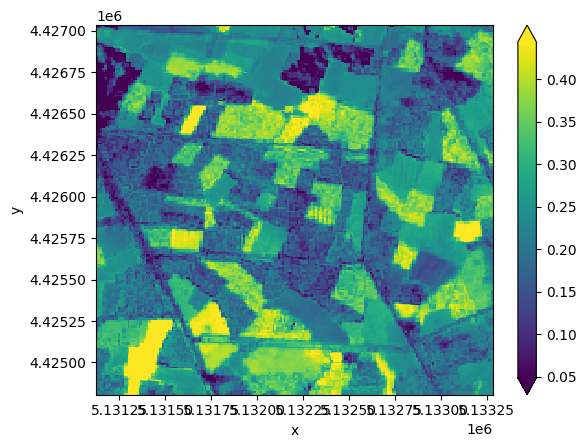

In [ ]:
threshold.plot(robust =True)

In [ ]:
ndvi_peak = ndvi_arr.idxmax(dim = 'time')
before = ndvi_arr.where(ndvi_arr.time <= ndvi_peak)
after = ndvi_arr.where(ndvi_arr.time >= ndvi_peak)

In [ ]:
sos = before.time.dt.dayofyear.where(
    before >= threshold
).min('time')

In [ ]:
eos = after.time.dt.dayofyear.where(
    after >= threshold
).max('time')

In [ ]:
los = eos - sos

In [ ]:
import matplotlib.pyplot as plt

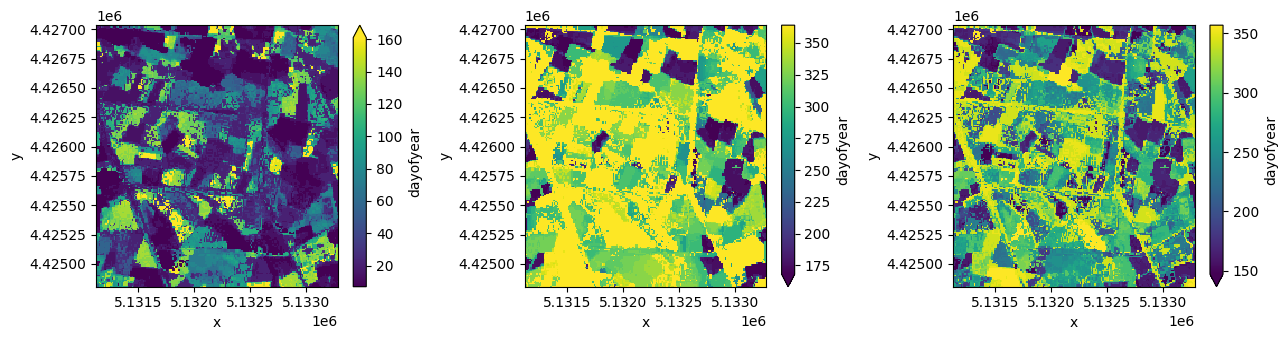

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (13, 3.5))

sos.plot(robust = True, ax = ax[0])
eos.plot(robust = True, ax = ax[1])
los.plot(robust = True, ax = ax[2])


plt.tight_layout()